In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Dropout, LSTM

In [8]:
# Đọc dữ liệu từ file CSV
file_path = "./DATA EXPLORER CONTEST/Data - 12ndMar/4.2.3.FPT.csv"
df = pd.read_csv(file_path)

# Xem thông tin tổng quan
print("Kích thước dữ liệu:", df.shape)
print("\nCác cột dữ liệu:\n", df.dtypes)
print("\nDữ liệu bị thiếu:\n", df.isnull().sum())
print("\n5 dòng đầu tiên của dữ liệu:")
print(df.head())


Kích thước dữ liệu: (240, 10)

Các cột dữ liệu:
 StockID            object
Date               object
Total Volume        int64
Total Value         int64
Market Cap          int64
Closing Price       int64
Price Change        int64
Price Change %    float64
Matched Volume      int64
Matched Value       int64
dtype: object

Dữ liệu bị thiếu:
 StockID           0
Date              0
Total Volume      0
Total Value       0
Market Cap        0
Closing Price     0
Price Change      0
Price Change %    0
Matched Volume    0
Matched Value     0
dtype: int64

5 dòng đầu tiên của dữ liệu:
  StockID       Date  Total Volume  Total Value  Market Cap  Closing Price  \
0     FPT  12/3/2025       6365000       870067   199918302         135900   
1     FPT  11/3/2025       6164400       849430   202272013         137500   
2     FPT  10/3/2025       5681900       796168   204919937         139300   
3     FPT   7/3/2025       3436000       486821   208009182         141400   
4     FPT   6/3/2025    

In [9]:
# Chuyển đổi cột 'Date' sang datetime
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

# Kiểm tra lại kiểu dữ liệu
print(df.dtypes)
print(df.head())

StockID                   object
Date              datetime64[ns]
Total Volume               int64
Total Value                int64
Market Cap                 int64
Closing Price              int64
Price Change               int64
Price Change %           float64
Matched Volume             int64
Matched Value              int64
dtype: object
  StockID       Date  Total Volume  Total Value  Market Cap  Closing Price  \
0     FPT 2025-03-12       6365000       870067   199918302         135900   
1     FPT 2025-03-11       6164400       849430   202272013         137500   
2     FPT 2025-03-10       5681900       796168   204919937         139300   
3     FPT 2025-03-07       3436000       486821   208009182         141400   
4     FPT 2025-03-06       6511400       921080   208303396         141600   

   Price Change  Price Change %  Matched Volume  Matched Value  
0         -1600           -1.16         6185000         844877  
1         -1800           -1.29         5784400         7

# Long Short Term Memory (LSTM)

In [10]:
# Sắp xếp dữ liệu theo thời gian
df = df.sort_values(by="Date")

# Tạo DataFrame và đặt Date làm index
Cls_price_FPT = df[['Date', 'Closing Price']].set_index('Date')
Cls_price_FPT

,Closing Price
Date,
2024-03-26,115000
2024-03-27,115200
2024-03-28,117100
2024-03-29,116500
2024-04-01,116800
...,...
2025-03-06,141600
2025-03-07,141400
2025-03-10,139300


In [11]:
# Chuyển DataFrame thành numpy array (chỉ lấy cột giá)
price_values = Cls_price_FPT['Closing Price'].values.reshape(-1, 1)

# Chia train/test trước khi scale để tránh data leakage
split = int(0.8 * len(price_values))
train, test = price_values[:split], price_values[split:]

In [12]:
# Scaling
scaler = MinMaxScaler(feature_range=(0, 1))
# Chỉ fit trên train set
train_scaled = scaler.fit_transform(train)
# Transform test set bằng scaler đã fit từ train
test_scaled = scaler.transform(test)

print(f"Train shape: {train_scaled.shape}, Test shape: {test_scaled.shape}")

Train shape: (192, 1), Test shape: (48, 1)


In [13]:
# Tạo cấu trúc dữ liệu với 60 time-steps và 1 output 

X_train, y_train = [], []
for i in range(60,len(train)):
    X_train.append(train_scaled[i-60:i,0])
    y_train.append(train_scaled[i,0])

In [14]:
# Chuyển X_train và y_train thành numpy arrays cho mô hình LSTM training 

X_train, y_train = np.array(X_train), np.array(y_train)

In [15]:
# Chuyển dạng dữ liệu thành 3D theo định dạng yêu cầu của LSTM (samples, time steps, features)

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

(132, 60, 1)

In [24]:
# Tạo và fit mạng LSTM 
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, epochs=50, batch_size=1, verbose=2)

# Dự đoán giá trị, sự dụng 60 từ tập data train 
inputs = price_values[len(price_values) - len(test) - 60:]
inputs = inputs.reshape(-1,1)
inputs  = scaler.transform(inputs)

Epoch 1/50


c:\Users\Dell\Downloads\Data_Explorer_2025\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


132/132 - 7s - 56ms/step - loss: 0.0341
Epoch 2/50
132/132 - 3s - 25ms/step - loss: 0.0278
Epoch 3/50
132/132 - 3s - 25ms/step - loss: 0.0198
Epoch 4/50
132/132 - 3s - 25ms/step - loss: 0.0191
Epoch 5/50
132/132 - 3s - 24ms/step - loss: 0.0156
Epoch 6/50
132/132 - 3s - 24ms/step - loss: 0.0156
Epoch 7/50
132/132 - 3s - 24ms/step - loss: 0.0163
Epoch 8/50
132/132 - 3s - 24ms/step - loss: 0.0133
Epoch 9/50
132/132 - 5s - 40ms/step - loss: 0.0126
Epoch 10/50
132/132 - 3s - 25ms/step - loss: 0.0162
Epoch 11/50
132/132 - 3s - 25ms/step - loss: 0.0147
Epoch 12/50
132/132 - 3s - 26ms/step - loss: 0.0111
Epoch 13/50
132/132 - 5s - 36ms/step - loss: 0.0106
Epoch 14/50
132/132 - 3s - 23ms/step - loss: 0.0101
Epoch 15/50
132/132 - 3s - 24ms/step - loss: 0.0115
Epoch 16/50
132/132 - 5s - 42ms/step - loss: 0.0110
Epoch 17/50
132/132 - 5s - 37ms/step - loss: 0.0091
Epoch 18/50
132/132 - 3s - 24ms/step - loss: 0.0086
Epoch 19/50
132/132 - 3s - 23ms/step - loss: 0.0080
Epoch 20/50
132/132 - 3s - 26ms/

In [25]:
# Tạo test data set
X_test = []
for i in range(60,inputs.shape[0]):
    X_test.append(inputs[i-60:i,0])

# Chuyển data thành numpy array
X_test = np.array(X_test)

# Chuyển data thành 3-D
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
adj_closing_price = model.predict(X_test)
adj_closing_price = scaler.inverse_transform(adj_closing_price)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000016A40160F40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 606ms/step


In [26]:
print(X_test.shape)

(48, 60, 1)


In [27]:
rmse = np.sqrt(np.mean(np.power((test - adj_closing_price),2)))
rmse

np.float64(1993.6664639936168)

C:\Users\Dell\AppData\Local\Temp\ipykernel_15656\236091463.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = adj_closing_price


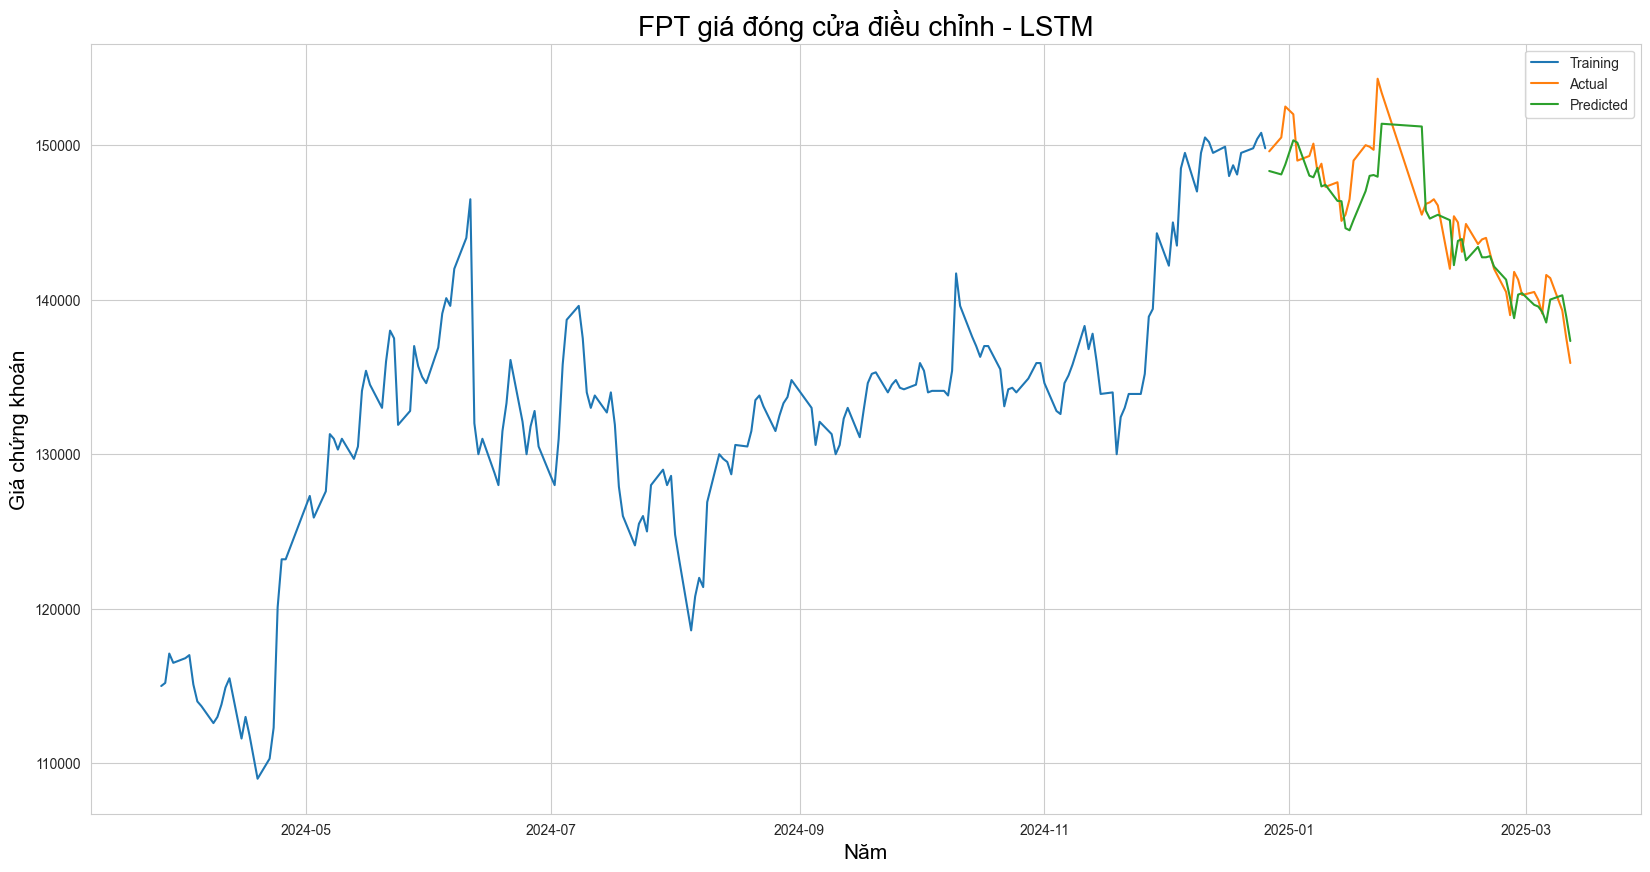

In [28]:
# Plot thông số dự đoán và thực tế
train = Cls_price_FPT[:split]
test = Cls_price_FPT[split:]
test['Predictions'] = adj_closing_price

plt.figure(figsize=(20,10))
sns.set_style("whitegrid")
plt.plot(train['Closing Price'], label='Training')
plt.plot(test['Closing Price'], label='Actual')
plt.plot(test['Predictions'], label='Predicted')
plt.title("FPT giá đóng cửa điều chỉnh - LSTM", color = 'black', fontsize = 20)
plt.xlabel('Năm', color = 'black', fontsize = 15)
plt.ylabel('Giá chứng khoán', color = 'black', fontsize = 15)
plt.legend();